In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Number 1

## A.

In [15]:
df = pd.read_excel("./Number-1-data.xlsx")
df

,Year (y),"Temperature (x, oC)"
0,1981,14.1999
1,1983,14.2411
2,1985,14.0342
3,1987,14.2696
4,1989,14.1970
5,1991,14.3055
6,1993,14.1853
7,1995,14.3577
8,1997,14.4187
9,1999,14.3438


In [16]:
df.set_index("Year (y)", inplace=True)

In [136]:
df.loc[1981]["Temperature (x, oC)"]

14.1999

In [137]:
def f(x) :
    return x

def f2(x2, x1) :
    y1 = df.loc[x1]["Temperature (x, oC)"]
    y2 = df.loc[x2]["Temperature (x, oC)"]
    return (y2 - y1) / (x2 - x1)

def f3(x3, x2, x1) :
    return ((f2(x3, x2)) - (f2(x2, x1))) / (x3 - x1)

def f4(x4, x3, x2, x1) :
    return ((f3(x4, x3, x2)) - (f3(x3, x2, x1))) / (x4 - x1)

def linear_interpolation (x, x2, x1) :
    y1 = df.loc[x1]["Temperature (x, oC)"]
    return round(y1 + (x - x1) * (f2(x2, x1)), 5)

def quadratic_interpolation (x, x3, x2, x1) :
    linear = linear_interpolation(x, x2, x1)
    y = linear + round(f3(x3, x2, x1), 8) * (x - x1) * (x - x2)
    # print(f"{linear} + {round(f3(x3, x2, x1), 8)} * ({x - x1}) * ({x - x2}) = {round(y, 7)}")
    return round(y, 7)

def cubic_interpolation (x, x4, x3, x2, x1) :
    quadrat = quadratic_interpolation (x, x3, x2, x1)
    y = quadrat + round(f4(x4, x3, x2, x1), 5) * (x - x1) * (x - x2) * (x - x3)
    print(f"{quadrat} + {round(f4(x4, x3, x2, x1), 5)} * ({x - x1}) * ({x - x2}) * ({x - x3}) = {round(y, 4)}")
    return round(y, 4)
    

x = 1982

for i in range(7) :
    x1 = x - 1
    x2 = x + 1
    x3 = x2 + 2
    x4 = x3 + 2

    # quadratic_interpolation(x, x3, x2, x1)
    cubic_interpolation(x, x4, x3, x2, x1)

    x = x + 2
print()



14.2515125 + 0.01438 * (1) * (-1) * (-3) = 14.2947
14.0823625 + -0.01563 * (1) * (-1) * (-3) = 14.0355
14.1904 + 0.01019 * (1) * (-1) * (-3) = 14.221
14.2106625 + -0.00854 * (1) * (-1) * (-3) = 14.185
14.2798375 + 0.01086 * (1) * (-1) * (-3) = 14.3124
14.208825 + -0.00842 * (1) * (-1) * (-3) = 14.1836
14.285425 + -0.00051 * (1) * (-1) * (-3) = 14.2839



## B.

In [2]:
df = pd.read_excel("./Number-1-data.xlsx")

In [3]:
df.rename(columns={'Year (y)' : 'x', 'Temperature (x, oC)' : 'y'}, inplace=True)

df['x2'] = df['x'] ** 2
df['y2'] = df['y'] ** 2
df['xy'] = df['x'] * df['y']

In [4]:
m = round((10 * sum(df['xy']) - sum(df['y']) * sum(df['x'])) / (10 * sum(df['x2']) - sum(df['x'])**2), 9)

b = round((sum(df['y']) - m * sum(df['x'])) / 10, 5)

def least_square(m, b, x) :
    return round(m * x + b, 4)

for i in df['x'] :
    print(f"{i + 1} -> {m} x {i + 1} + ({b}) = {least_square(m, b, i + 1)}")

1982 -> 0.012155758 x 1982 + (-9.93468) = 14.158
1984 -> 0.012155758 x 1984 + (-9.93468) = 14.1823
1986 -> 0.012155758 x 1986 + (-9.93468) = 14.2067
1988 -> 0.012155758 x 1988 + (-9.93468) = 14.231
1990 -> 0.012155758 x 1990 + (-9.93468) = 14.2553
1992 -> 0.012155758 x 1992 + (-9.93468) = 14.2796
1994 -> 0.012155758 x 1994 + (-9.93468) = 14.3039
1996 -> 0.012155758 x 1996 + (-9.93468) = 14.3282
1998 -> 0.012155758 x 1998 + (-9.93468) = 14.3525
2000 -> 0.012155758 x 2000 + (-9.93468) = 14.3768


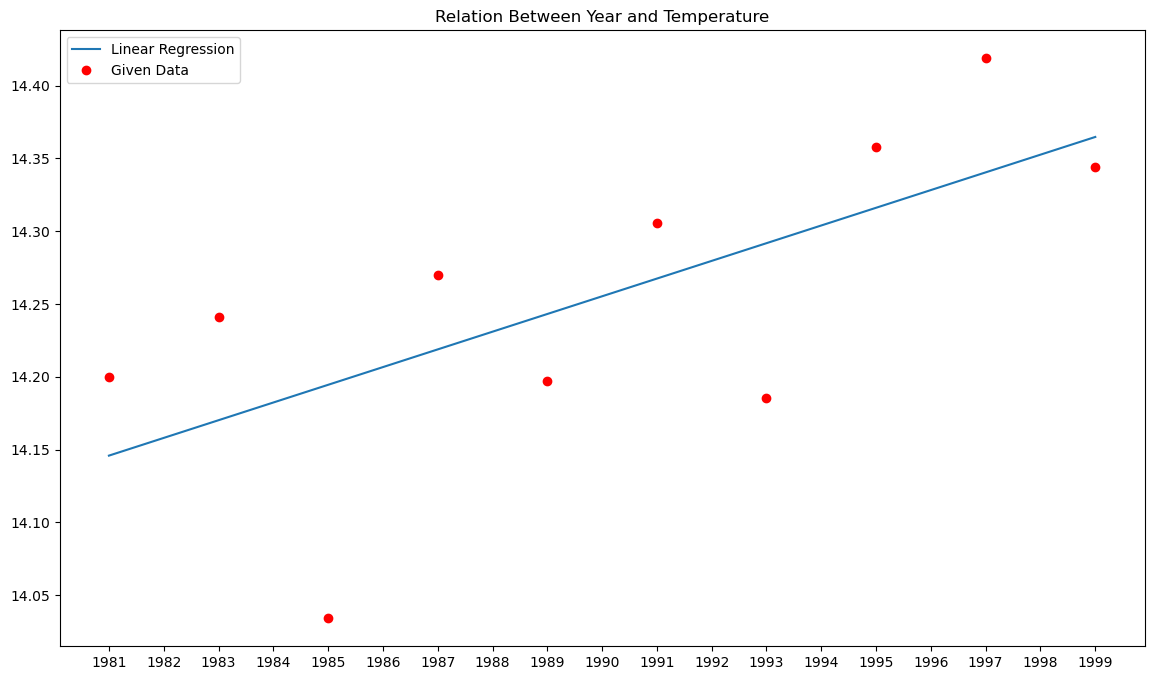

In [9]:
x = np.array(df["x"]) 
y = np.array(df["y"]) 

#plotting
plt.figure(figsize = (14, 8))
plt.plot(x, m*x+b, label="Linear Regression")
plt.plot(x, y, "ro",label="Given Data")
plt.title("Relation Between Year and Temperature")
plt.xticks(np.arange(min(x), max(x) + 1, 1))
plt.legend()
plt.show()

# Number 2

## A.

In [25]:
import sympy as sm

In [26]:
x = sm.symbols('x')

def taylor(f, order, x0) :
    t = 0
    for i in range(0, order) :
        t = t + (sm.diff(f, x, i).subs(x, x0) / sm.factorial(i)) * (x ** i)
    return t

In [27]:
sin_formula = taylor(sm.sin(x), 8, 0)
sin_formula

-x**7/5040 + x**5/120 - x**3/6 + x

In [29]:
cos_formula = taylor(sm.cos(x), 8, 0)
cos_formula

-x**6/720 + x**4/24 - x**2/2 + 1

In [30]:
sincos_formula = taylor(sm.sin(x) * sm.cos(x), 8, 0)
sincos_formula

-4*x**7/315 + 2*x**5/15 - 2*x**3/3 + x

## B.

In [34]:
import sympy as sm

In [42]:
x = sm.symbols('x')
x_value = (np.pi) / 2

# Taylor Expansion Around 0
a = 0

approx_1 = sin_formula.subs(x, x_value) * cos_formula.subs(x, x_value)
approx_2 = sincos_formula.subs(x, x_value)
exact_value = np.sin(x_value) * np.cos(x_value)

error_approx_1 = np.abs(approx_1 - exact_value)
error_approx_2 = np.abs(approx_2 - exact_value)

print("Comparing approach")
print(f"Error of Approach 1: {error_approx_1}")
print(f"Error of Approach 2: {error_approx_2}")

Comparing approach
Error of Approach 1: 0.000894382649068296
Error of Approach 2: 0.0376103079518116


## C

In [43]:
x_value = (np.pi) / 4
cos_approx = cos_formula.subs(x, x_value)
exact_value = np.cos(x_value)
error = np.abs(cos_approx - exact_value)

print("Taylor series for cos(X)")
print(f"Exact Value: {exact_value}")
print(f"Approximation: {cos_approx}")
print(f"Error: {error}")
print()

Taylor series for cos(X)
Exact Value: 0.7071067811865476
Approximation: 0.707103214822846
Error: 0.00000356636370191232

